In [64]:
import os
import numpy as np
import networkx as nx
from networkx.algorithms import bipartite as bp
import pandas as pd
import json

In [65]:
# Load the genres data
with open('HR_genres.json', 'r') as f:
    genres_data = json.load(f)

In [66]:
# Create a list of (user, genre) tuples
user_genre_pairs = [(user, genre) for user, genres in genres_data.items() for genre in genres]

In [67]:
# Create a DataFrame
df = pd.DataFrame(user_genre_pairs, columns=['user', 'genre'])

In [68]:
# Create a bipartite graph
B = nx.Graph()
B.add_nodes_from(df['user'].unique(), bipartite=0)
B.add_nodes_from(df['genre'].unique(), bipartite=1)
B.add_edges_from(df.itertuples(index=False))

In [69]:
# Project the graph onto genres
genre_graph = bp.weighted_projected_graph(B, df['genre'].unique())

# Normalize edge weights
for u, v, d in genre_graph.edges(data=True):
    d['weight'] = d['weight'] / len(genres_data)

In [70]:
# Get edge data
edge_data = [(u, v, d['weight']) for u, v, d in genre_graph.edges(data=True)]

# Sort by weight in descending order
sorted_edges = sorted(edge_data, key=lambda x: x[2], reverse=True)

In [71]:
# Print top 10 most similar genre pairs
print("Top 10 most similar genre pairs:")
for genre1, genre2, weight in sorted_edges[:10]:
    print(f"{genre1} - {genre2}: {weight:.4f}")

Top 10 most similar genre pairs:
Pop - Dance: 0.4508
Pop - Rock: 0.4412
Pop - Alternative: 0.3601
Pop - Rap/Hip Hop: 0.3563
Pop - Electro: 0.3302
Dance - Electro: 0.3283
Rock - Alternative: 0.2917
Rap/Hip Hop - Dance: 0.2894
Rock - Dance: 0.2890
Pop - R&B: 0.2713


In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
# Create a similarity matrix
genres = list(genre_graph.nodes())
n_genres = len(genres)
similarity_matrix = np.zeros((n_genres, n_genres))

for i, genre1 in enumerate(genres):
    for j, genre2 in enumerate(genres):
        if genre_graph.has_edge(genre1, genre2):
            similarity_matrix[i, j] = genre_graph[genre1][genre2]['weight']

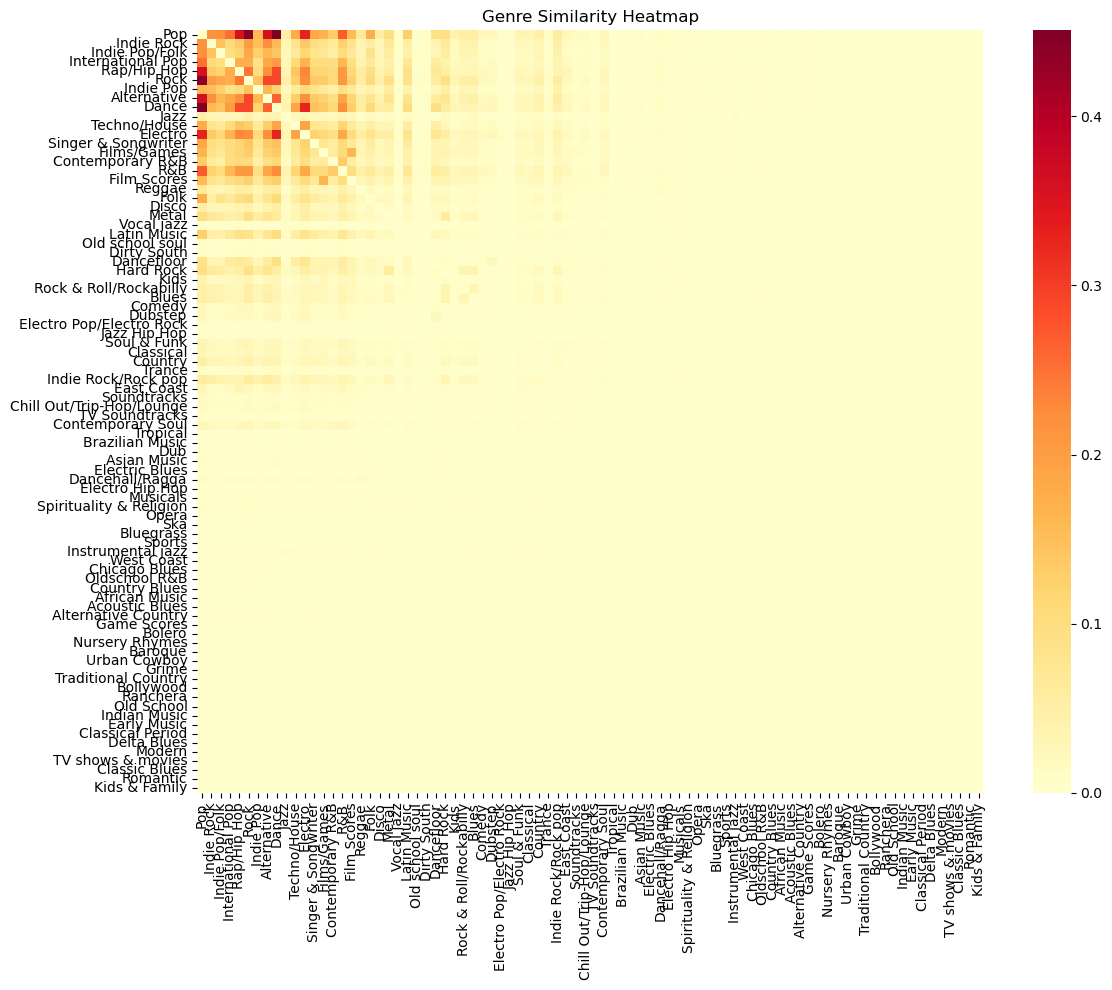

In [74]:
# Create a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(similarity_matrix, xticklabels=genres, yticklabels=genres, cmap='YlOrRd')
plt.title('Genre Similarity Heatmap')
plt.tight_layout()
plt.show()

In [75]:
centrality = nx.eigenvector_centrality(genre_graph)
top_genres = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 most central genres:")
for genre, score in top_genres:
    print(f"{genre}: {score:.4f}")

Top 10 most central genres:
Pop: 0.1258
Rock: 0.1258
Electro: 0.1258
Films/Games: 0.1258
Film Scores: 0.1258
Indie Rock: 0.1254
Indie Pop/Folk: 0.1254
Indie Pop: 0.1254
Alternative: 0.1254
Folk: 0.1254


In [76]:
from networkx.algorithms import community

In [77]:
# Apply Louvain community detection
louvain_communities = community.louvain_communities(genre_graph, weight='weight')

print("Louvain communities:")
for i, comm in enumerate(louvain_communities):
    print(f"Community {i + 1}: {', '.join(sorted(comm))}")

#The colors in the visualization represent different communities detected by the Louvain algorithm:
#Red nodes form one major community, including genres like "Hip Hop", "R&B", and related urban music styles
#Turquoise nodes represent another community, including "Game Scores" and entertainment-related genres
#Purple nodes form another distinct community of electronic and dance music genres

Louvain communities:
Community 1: Alternative, Asian Music, Comedy, Contemporary R&B, Dance, Dancefloor, Disco, Dubstep, Electro, Electro Hip Hop, Electro Pop/Electro Rock, Folk, International Pop, Latin Music, Pop, R&B, Rap/Hip Hop, Rock, Singer & Songwriter, Sports, Techno/House, Trance
Community 2: Film Scores, Films/Games, Game Scores, Kids, Kids & Family, Musicals, Nursery Rhymes, Soundtracks, TV Soundtracks
Community 3: Dancehall/Ragga, Dirty South, Dub, East Coast, Grime, Ranchera, Reggae, Ska, West Coast
Community 4: Acoustic Blues, African Music, Alternative Country, Baroque, Bluegrass, Blues, Bolero, Bollywood, Brazilian Music, Chicago Blues, Chill Out/Trip-Hop/Lounge, Classic Blues, Classical, Classical Period, Contemporary Soul, Country, Country Blues, Delta Blues, Early Music, Electric Blues, Hard Rock, Indian Music, Indie Pop, Indie Pop/Folk, Indie Rock, Indie Rock/Rock pop, Instrumental jazz, Jazz, Jazz Hip Hop, Metal, Modern, Old School, Old school soul, Oldschool R&B, 

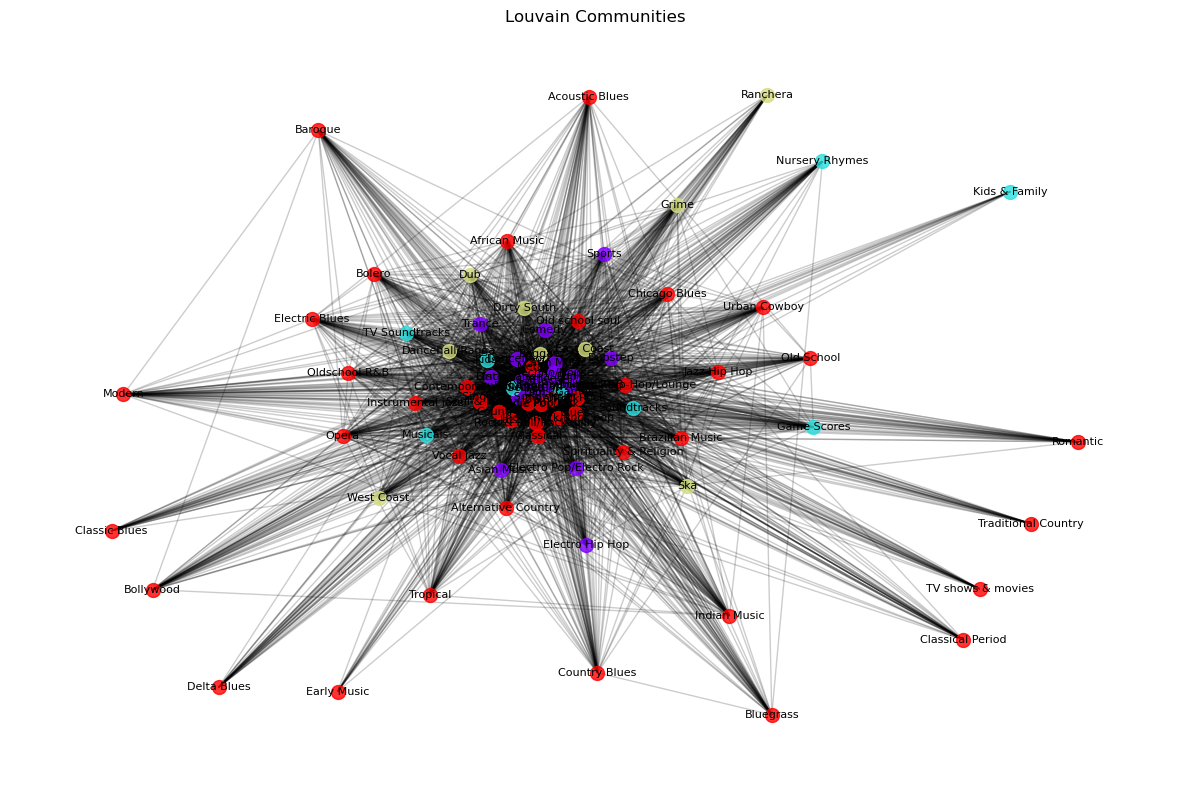

In [78]:
def plot_communities(G, communities, title):
    pos = nx.spring_layout(G)
    plt.figure(figsize=(12, 8))
    
    colors = plt.cm.rainbow(np.linspace(0, 1, len(communities)))
    
    for i, comm in enumerate(communities):
        nx.draw_networkx_nodes(G, pos, nodelist=comm, node_color=[colors[i]], node_size=100, alpha=0.8)
    
    nx.draw_networkx_edges(G, pos, alpha=0.2)
    nx.draw_networkx_labels(G, pos, font_size=8)
    
    # Create ScalarMappable for colorbar
    sm = plt.cm.ScalarMappable(cmap=plt.cm.rainbow, 
                              norm=plt.Normalize(vmin=0, vmax=len(communities)-1))
    sm.set_array([])

    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_communities(genre_graph, louvain_communities, "Louvain Communities")
#plot_communities(genre_graph, gn_partition, "Girvan-Newman Communities")

In [79]:
louvain_modularity = community.modularity(genre_graph, louvain_communities, weight='weight')
print(f"\nLouvain Modularity: {louvain_modularity:.4f}")



Louvain Modularity: 0.0359


In [ ]:
def community_density(G, community):
    subgraph = G.subgraph(community)
    return nx.density(subgraph)

print("\nCommunity Densities:")
for i, comm in enumerate(louvain_communities):
    density = community_density(genre_graph, comm)
    print(f"Louvain Community {i + 1}: {density:.4f}")


Community Densities:
Louvain Community 1: 1.0000
Louvain Community 2: 0.8056
Louvain Community 3: 0.8611
Louvain Community 4: 0.7019


In [81]:
# create social ties analysis 

import pandas as pd
import networkx as nx
import json

# Load the edges and genres data
edges_df = pd.read_csv('HR_edges.csv')
with open('HR_genres.json', 'r') as f:
    genres_data = json.load(f)

# Create friendship network
friendship_graph = nx.from_edgelist(edges_df.values)

# Function to calculate genre overlap between two users
def calculate_genre_overlap(user1, user2, genres_data):
    user1_genres = set(genres_data.get(str(user1), []))
    user2_genres = set(genres_data.get(str(user2), []))
    return len(user1_genres.intersection(user2_genres))

# Analyze edges and classify them
social_ties = []
non_social_ties = []

for edge in edges_df.values:
    user1, user2 = edge
    genre_overlap = calculate_genre_overlap(user1, user2, genres_data)
    
    if genre_overlap > 0:
        social_ties.append((user1, user2, genre_overlap))
    else:
        non_social_ties.append((user1, user2))

# Create networks for both types of ties
social_network = nx.Graph()
social_network.add_weighted_edges_from(social_ties)

non_social_network = nx.Graph()
non_social_network.add_edges_from(non_social_ties)

In [82]:
# Analyse network characteristics

# Calculate network metrics
print(f"Social Ties Network:")
print(f"Number of edges: {social_network.number_of_edges()}")
print(f"Number of nodes: {social_network.number_of_nodes()}")
print(f"Average clustering coefficient: {nx.average_clustering(social_network):.4f}")

print(f"\nNon-Social Ties Network:")
print(f"Number of edges: {non_social_network.number_of_edges()}")
print(f"Number of nodes: {non_social_network.number_of_nodes()}")
print(f"Average clustering coefficient: {nx.average_clustering(non_social_network):.4f}")

Social Ties Network:
Number of edges: 439049
Number of nodes: 53851
Average clustering coefficient: 0.1294

Non-Social Ties Network:
Number of edges: 59153
Number of nodes: 30101
Average clustering coefficient: 0.0388


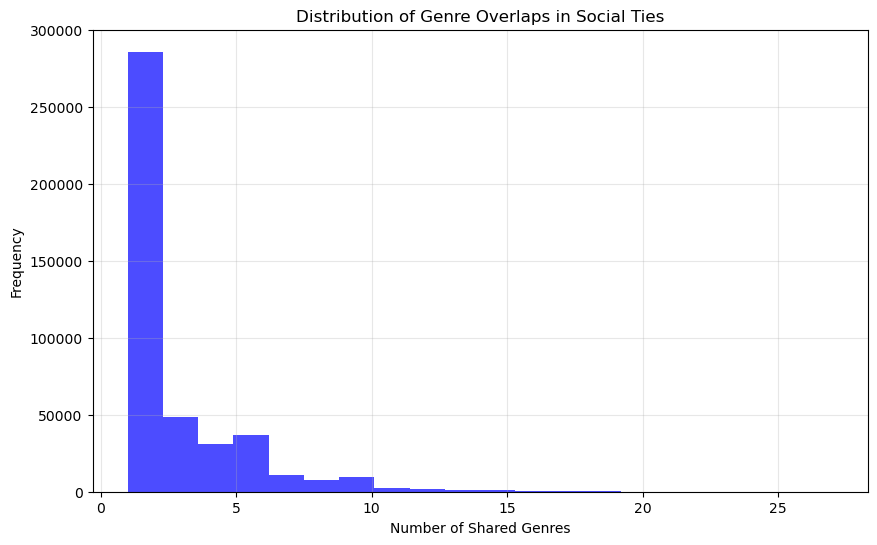

In [83]:
# Visualize distribution of genre overlaps 

import matplotlib.pyplot as plt

# Extract genre overlap weights
overlap_weights = [d['weight'] for _, _, d in social_network.edges(data=True)]

plt.figure(figsize=(10, 6))
plt.hist(overlap_weights, bins=20, alpha=0.7, color='blue')
plt.title('Distribution of Genre Overlaps in Social Ties')
plt.xlabel('Number of Shared Genres')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

#The histogram shows how many shared genres exist between connected users:
#The majority of connections (approximately 280,000) share only 1-2 genres
#There's a sharp decline in frequency as the number of shared genres increases
#Very few user pairs share more than 10 genres
#The distribution is heavily right-skewed, indicating that most social connections are based on a small number of common musical interests

In [84]:
# Compare network properties

def analyze_network_properties(G, name):
    degrees = [d for _, d in G.degree()]
    avg_degree = sum(degrees) / len(degrees)
    
    return {
        'name': name,
        'avg_degree': avg_degree,
        'density': nx.density(G),
        'components': nx.number_connected_components(G)
    }

social_props = analyze_network_properties(social_network, 'Social Ties')
non_social_props = analyze_network_properties(non_social_network, 'Non-Social Ties')

# Create comparison table
properties_df = pd.DataFrame([social_props, non_social_props])
print("\nNetwork Properties Comparison:")
print(properties_df.to_string(index=False))


Network Properties Comparison:
           name  avg_degree  density  components
    Social Ties   16.306067 0.000303          20
Non-Social Ties    3.930301 0.000131         283
